In [12]:
import pandas as pd
import numpy as np



In [13]:
df = pd.read_csv("../Data/cleaned_data.csv")

In [11]:
df.shape

(109304, 37)

Clean data
Drop useless columns
Encode categorical features
Handle skewness
Check outliers
Create daily target
Aggregate features daily
Create lag + rolling features
Split train/test
Ready for model training

In [14]:
#Drop Unnecessary Columns
df = df.drop(columns=['appointment_time'], errors='ignore')

In [15]:
print(
    df['appointment_date_continuous']
    .head(10)
)

0    01-01-2020
1    01-01-2020
2    01-01-2020
3    01-01-2020
4    01-01-2020
5    01-01-2020
6    01-01-2020
7    01-01-2020
8    01-01-2020
9    01-01-2020
Name: appointment_date_continuous, dtype: object


In [16]:
df['appointment_date_continuous'] = pd.to_datetime(
    df['appointment_date_continuous'],
    format='%d-%m-%Y',
    errors='coerce'
)

In [17]:
print(df['appointment_date_continuous'].dtype)

print("df")

datetime64[ns]
df


In [18]:
print(
    df['appointment_date_continuous']
    .isna()
    .sum()
)

0


In [19]:
#Clean Missing Values
#(Numerical columns)

num_cols = [
    'age',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

In [20]:
#Binary columns

binary_cols = [
    'SMS_received',
    'patient_needs_companion',
    'under_12_years_old',
    'over_60_years_old',
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'Scholarship',
    'rainy_day_before',
    'storm_day_before'
]

for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(0).astype(int)

In [21]:
#Convert yes/no → numeric ,no_show
df['no_show'] = (
    df['no_show']
    .astype(str)
    .str.lower()
    .map({'yes':1, 'no':0})
)

df['no_show'] = df['no_show'].fillna(0)


In [22]:
#Encoding Over categorical coloumn
cat_cols = [
    'specialty',
     'gender',
    'appointment_shift',
    'disability',
    'rain_intensity',
    'heat_intensity'
]

for col in cat_cols:
    print(col)
    print(df[col].unique()[:10])

specialty
['psychotherapy' 'speech therapy' 'physiotherapy' 'occupational therapy'
 'assist' 'pedagogo' 'enf' 'sem especialidade']
gender
['F' 'M']
appointment_shift
['afternoon' 'morning']
disability
['intellectual' 'motor' 'none']
rain_intensity
['no_rain' 'moderate' 'weak' 'heavy']
heat_intensity
['warm' 'cold' 'mild' 'heavy_warm' 'heavy_cold']


In [23]:
print(df[cat_cols].isnull().sum())

specialty            0
gender               0
appointment_shift    0
disability           0
rain_intensity       0
heat_intensity       0
dtype: int64


In [25]:
print(df['place'].nunique())

26229


In [26]:
place_freq = df['place'].value_counts()

df['place_encoded'] = df['place'].map(place_freq)

In [27]:
#One-Hot Encoding (BEST FOR YOUR DATA)
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

In [28]:
print(df.shape)

print(
    df.memory_usage(deep=True)
    .sum() / 1024**2,
    "MB"
)

(109304, 38)
37.73073387145996 MB


In [29]:
print(
    df.select_dtypes(include='object').columns
)

Index(['place'], dtype='object')


In [30]:
print(df.select_dtypes(include='object').columns.tolist())

['place']


In [31]:
df.dtypes

no_show                                    int64
place                                     object
age                                      float64
under_12_years_old                         int64
over_60_years_old                          int64
patient_needs_companion                    int64
average_temp_day                         float64
average_rain_day                         float64
max_temp_day                             float64
max_rain_day                             float64
rainy_day_before                           int64
storm_day_before                           int64
appointment_date_continuous       datetime64[ns]
Hipertension                               int64
Diabetes                                   int64
Alcoholism                                 int64
Handcap                                    int64
Scholarship                                int64
SMS_received                               int64
place_encoded                              int64
specialty_enf       

In [32]:
print(df.select_dtypes(include='object').columns.tolist())

['place']


In [33]:
if 'place' in df.columns:
    df.drop(columns=['place'], inplace=True)
    print("place column removed")
else:
    print("place already removed")

place column removed


In [34]:
print(df.select_dtypes(include='object').columns.tolist())


[]


In [35]:
print(df.dtypes.value_counts())

print("Missing values:",
      df.isnull().sum().sum())

print("Object columns:",
      df.select_dtypes(include='object').columns.tolist())

int64             31
float64            5
datetime64[ns]     1
Name: count, dtype: int64
Missing values: 0
Object columns: []


int64             31
float64            5
datetime64[ns]     1
Name: count, dtype: int64
Missing values: 0
Object columns: []

appointment_date_continuous → datetime64[ns]

In [36]:
print(df.columns)

Index(['no_show', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'Scholarship', 'SMS_received', 'place_encoded',
       'specialty_enf', 'specialty_occupational therapy', 'specialty_pedagogo',
       'specialty_physiotherapy', 'specialty_psychotherapy',
       'specialty_sem especialidade', 'specialty_speech therapy', 'gender_M',
       'appointment_shift_morning', 'disability_motor', 'disability_none',
       'rain_intensity_moderate', 'rain_intensity_no_rain',
       'rain_intensity_weak', 'heat_intensity_heavy_cold',
       'heat_intensity_heavy_warm', 'heat_intensity_mild',
       'heat_intensity_warm'],
      dtype='object')


In [37]:
df = df.set_index('appointment_date_continuous')

df = df.sort_index()

In [38]:
print(df.index)

DatetimeIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01',
               ...
               '2021-05-11', '2021-05-11', '2021-05-11', '2021-05-11',
               '2021-05-11', '2021-05-11', '2021-05-11', '2021-05-11',
               '2021-05-11', '2021-05-12'],
              dtype='datetime64[ns]', name='appointment_date_continuous', length=109304, freq=None)


In [39]:
df.head()

,no_show,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,...,appointment_shift_morning,disability_motor,disability_none,rain_intensity_moderate,rain_intensity_no_rain,rain_intensity_weak,heat_intensity_heavy_cold,heat_intensity_heavy_warm,heat_intensity_mild,heat_intensity_warm
appointment_date_continuous,,,,,,,,,,,,,,,,,,,,,
2020-01-01,1,9.0,1,0,1,23.18,0.00,27.5,0.0,1,...,0,0,0,0,1,0,0,0,0,1
2020-01-01,0,11.0,1,0,1,14.31,0.02,16.5,0.6,1,...,1,0,0,0,1,0,0,0,0,0
2020-01-01,0,8.0,1,0,1,21.61,0.01,29.9,0.2,1,...,0,0,0,0,1,0,0,0,0,1
2020-01-01,1,9.0,1,0,1,21.39,0.11,24.1,1.4,1,...,0,0,0,1,0,0,0,0,1,0
2020-01-01,0,12.0,0,0,0,20.15,0.02,23.1,0.2,1,...,1,1,0,0,1,0,0,0,1,0


In [40]:
skewness = df.select_dtypes(
    include=['int64','float64']
).skew().sort_values(ascending=False)

print(skewness)

specialty_sem especialidade       18.285792
Handcap                           10.326908
specialty_enf                      7.876581
heat_intensity_heavy_warm          7.758817
Alcoholism                         7.152476
Diabetes                           6.242492
specialty_pedagogo                 5.288047
average_rain_day                   4.016277
max_rain_day                       3.918658
Scholarship                        3.906110
Hipertension                       3.783995
over_60_years_old                  3.325686
heat_intensity_heavy_cold          3.201322
rain_intensity_weak                2.626856
specialty_occupational therapy     2.603190
age                                2.528921
rain_intensity_moderate            1.999945
disability_none                    1.902859
specialty_physiotherapy            1.563181
specialty_speech therapy           1.468069
heat_intensity_warm                1.460475
disability_motor                   1.026454
place_encoded                   

In [41]:
#TRANSFORM CONTINUOUS NUMERIC FEATURES
continuous_cols = [
    'age',
    'average_rain_day',
    'max_rain_day',
    'average_temp_day',
    'max_temp_day',
    'place_encoded'
]

In [42]:
#Check skew > 1 only
skewness = df[continuous_cols].skew()

print(skewness)

age                 2.528921
average_rain_day    4.016277
max_rain_day        3.918658
average_temp_day   -0.345826
max_temp_day        0.007073
place_encoded       0.861575
dtype: float64


DO NOT LOG TRANSFORM
age 
place_encoded 
binary features 
dummy variables 

Because:

XGBoost handles skewness well
too much transformation reduces interpretability
binary features become meaningless after log

In [43]:
#handle the Skewness in these coloumn
import numpy as np

skew_cols = [
    'average_rain_day',
    'max_rain_day'
]

for col in skew_cols:
    df[col] = np.log1p(df[col])

Check outliers ONLY for continuous numeric columns

NOT check every numeric column.

Some columns are naturally bounded or encoded and don’t need outlier treatment.

Because place_encoded is frequency encoded, not a real continuous measurement.

In [44]:
outlier_cols = [
    'age',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

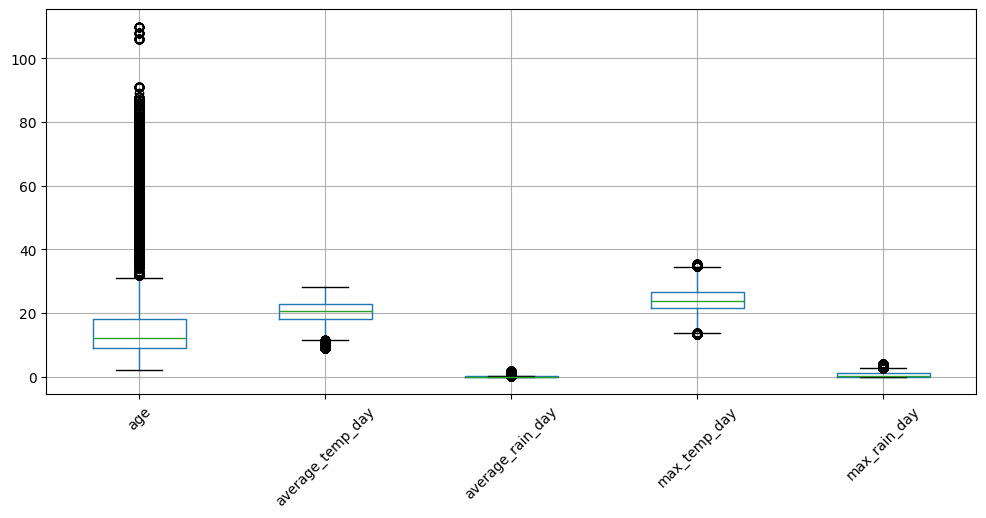

In [45]:
import matplotlib.pyplot as plt

outlier_cols = [
    'age',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

df[outlier_cols].boxplot(figsize=(12,5))

plt.xticks(rotation=45)
plt.show()

In [47]:
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    print(f"{col}: {outliers} outliers")

age: 11970 outliers
average_temp_day: 926 outliers
average_rain_day: 13879 outliers
max_temp_day: 512 outliers
max_rain_day: 4440 outliers


In [48]:
clip_cols = [
    'age',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day'
]

for col in clip_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outlier clipping done")

Outlier clipping done


In [49]:
for col in clip_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    print(f"{col}: {outliers} outliers")

age: 0 outliers
average_temp_day: 0 outliers
average_rain_day: 0 outliers
max_temp_day: 0 outliers


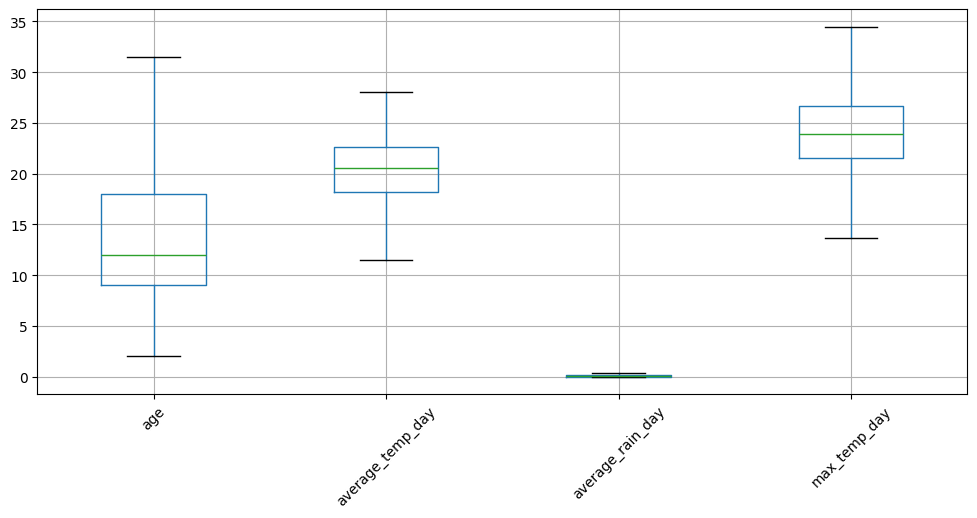

In [50]:
import matplotlib.pyplot as plt

outlier_cols = [
   'age',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day'
]
df[outlier_cols].boxplot(figsize=(12,5))

plt.xticks(rotation=45)
plt.show()

In [51]:
df.head

<bound method NDFrame.head of                              no_show   age  under_12_years_old  \
appointment_date_continuous                                      
2020-01-01                         1   9.0                   1   
2020-01-01                         0  11.0                   1   
2020-01-01                         0   8.0                   1   
2020-01-01                         1   9.0                   1   
2020-01-01                         0  12.0                   0   
...                              ...   ...                 ...   
2021-05-11                         1  18.0                   0   
2021-05-11                         1  18.0                   0   
2021-05-11                         0   8.0                   1   
2021-05-11                         0   7.0                   1   
2021-05-12                         0  12.0                   0   

                             over_60_years_old  patient_needs_companion  \
appointment_date_continuous         

In [52]:
print(df.index.dtype)

datetime64[ns]


In [54]:
print(df.index[:10])

DatetimeIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01'],
              dtype='datetime64[ns]', name='appointment_date_continuous', freq=None)


In [55]:
print(type(df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [56]:
print(df.index.isna().sum())

0


In [57]:
df.shape

(109304, 36)

In [58]:
df.columns

Index(['no_show', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship',
       'SMS_received', 'place_encoded', 'specialty_enf',
       'specialty_occupational therapy', 'specialty_pedagogo',
       'specialty_physiotherapy', 'specialty_psychotherapy',
       'specialty_sem especialidade', 'specialty_speech therapy', 'gender_M',
       'appointment_shift_morning', 'disability_motor', 'disability_none',
       'rain_intensity_moderate', 'rain_intensity_no_rain',
       'rain_intensity_weak', 'heat_intensity_heavy_cold',
       'heat_intensity_heavy_warm', 'heat_intensity_mild',
       'heat_intensity_warm'],
      dtype='object')

In [59]:
df.to_csv(
    "../data/cleaned_forecasting_data.csv"
)

In [60]:
df.shape

(109304, 36)